# **IT-549 Development Challange:**

##**Multimodal Semantic Alignment Challenge**

##**Name: Het Rank**

##**Student_ID: 202301081**

In [1]:
!pip install -q transformers==4.40.0 open-clip-torch kaggle Pillow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KAGGLE_API_KEY"
os.environ["KAGGLE_USERNAME"] = "Het_Rank_202301081"

!kaggle competitions download -c multimodal-semantic-alignment-challenge-for-deep-learning-course

100% 1.26G/1.26G [00:11<00:00, 119MB/s]



In [3]:
import zipfile
import os

zip_file_path = '/content/multimodal-semantic-alignment-challenge-for-deep-learning-course.zip'
extraction_path = '/content/multimodal_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f'Dataset extracted to: {extraction_path}')

# List the contents of the extracted directory to understand the structure
print('Contents of extracted directory:')
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Dataset extracted to: /content/multimodal_data
Contents of extracted directory:
multimodal_data/
    image_pool.csv
    caption_pool.csv
    sample_submission.csv
    test.csv
    train.csv
    val.csv
    test_images/
        test_images/
            294111300.jpg
            2904377891.jpg
            289262437.jpg
            29320965.jpg
            293809422.jpg
            2872778569.jpg
            2895966469.jpg
            2853682342.jpg
            2871691966.jpg
            288508162.jpg
            2937606915.jpg
            2930980889.jpg
            2888702775.jpg
            2909609550.jpg
            2924305507.jpg
            2892467862.jpg
            2888499869.jpg
            2887171449.jpg
            2895403073.jpg
            2835367658.jpg
            2852672275.jpg
            2894229082.jpg
            2834752476.jpg
            2832453252.jpg
            2856252334.jpg
            2942798367.jpg
            2860035355.jpg
            2888517039.jpg
          

In [8]:
import os

# Declaring the path of each files and directories of the data
BASE_DIR = "/content/multimodal_data"

TRAIN_CSV        = f"{BASE_DIR}/train.csv"
VAL_CSV          = f"{BASE_DIR}/val.csv"
TEST_CSV         = f"{BASE_DIR}/test.csv"
CAPTION_POOL_CSV = f"{BASE_DIR}/caption_pool.csv"
IMAGE_POOL_CSV   = f"{BASE_DIR}/image_pool.csv"
SAMPLE_SUB_CSV   = f"{BASE_DIR}/sample_submission.csv"

TRAIN_IMG_DIR    = f"{BASE_DIR}/train_images/train_images/"
VAL_IMG_DIR      = f"{BASE_DIR}/val_images/val_images"
TEST_IMG_DIR     = f"{BASE_DIR}/test_images/test_images"

OUTPUT_DIR       = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths configured ✅")

Paths configured ✅


## Explore the Data

In [9]:
import pandas as pd

train_df    = pd.read_csv(TRAIN_CSV)
val_df      = pd.read_csv(VAL_CSV)
test_df     = pd.read_csv(TEST_CSV)
caption_df  = pd.read_csv(CAPTION_POOL_CSV)
image_df    = pd.read_csv(IMAGE_POOL_CSV)

print(f"Train pairs   : {len(train_df):,}")
print(f"Val pairs     : {len(val_df):,}")
print(f"Test queries  : {len(test_df):,}")
print(f"Caption pool  : {len(caption_df):,}")
print(f"Image pool    : {len(image_df):,}")
print()
print("── test.csv sample ──")
print(test_df.head(4))
print()
print("── caption_pool sample ──")
print(caption_df.head(3))

Train pairs   : 40,000
Val pairs     : 5,000
Test queries  : 1,000
Caption pool  : 50,000
Image pool    : 10,000

── test.csv sample ──
   id  query query_type
0   1   9422      image
1   2   9880      image
2   3   9601      image
3   4   9511      image

── caption_pool sample ──
   caption_id  image_id                                            caption
0           1         1  Two young guys with shaggy hair look at their ...
1           2         1  Two young , White males are outside near many ...
2           3         1   Two men in green shirts are standing in a yard .


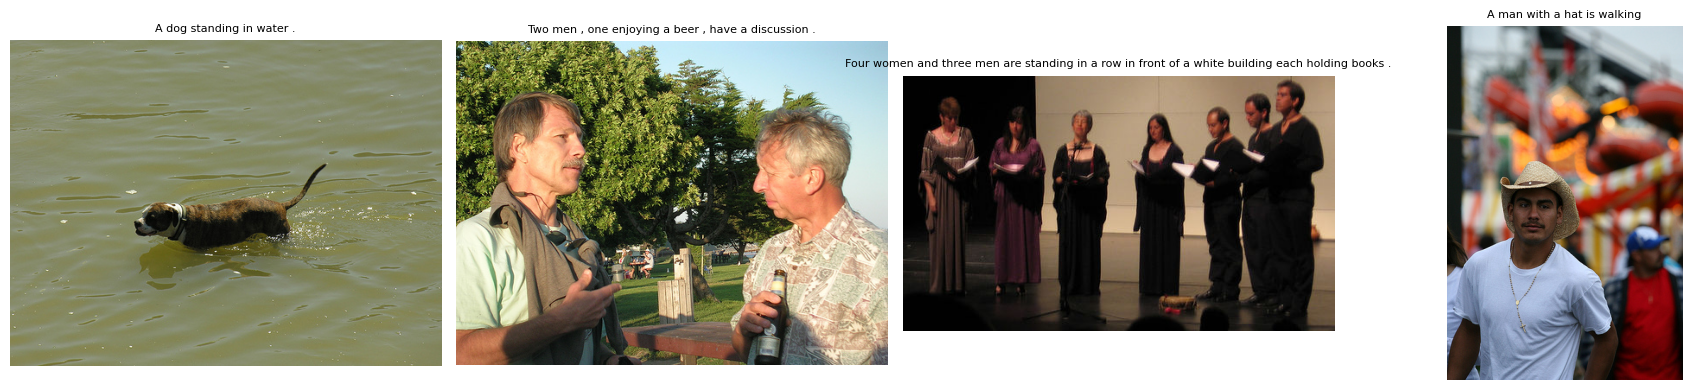

In [10]:
# Visualise a few training examples
import matplotlib.pyplot as plt
from PIL import Image

id2filename = dict(zip(image_df.image_id, image_df.image_name))
id2caption  = dict(zip(caption_df.caption_id, caption_df.caption))

sample = train_df.sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (_, row) in zip(axes, sample.iterrows()):
    img_path = os.path.join(TRAIN_IMG_DIR, id2filename[row.image_id])
    img      = Image.open(img_path).convert("RGB")
    cap      = id2caption[row.caption_id]
    ax.imshow(img)
    ax.set_title(cap, fontsize=8, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Config & Imports

In [16]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor
from tqdm.auto import tqdm
import numpy as np

# Hyperparameters
MODEL_NAME  = "openai/clip-vit-base-patch32"
BATCH_SIZE  = 64
ACCUM_STEPS = 4
LR          = 2e-5
EPOCHS      = 5
MAX_LEN     = 77
EMBED_DIM   = 512
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


##PyTorch Dataset

In [17]:
class ImageCaptionDataset(Dataset):
    """
    Returns one (image, caption) pair per __getitem__.
    Each image has 5 captions — we cycle through all of them.
    """
    def __init__(self, csv_path, image_dir, processor,
                 id2filename, id2caption):
        self.df          = pd.read_csv(csv_path)
        self.image_dir   = image_dir
        self.processor   = processor
        self.id2filename = id2filename
        self.id2caption  = id2caption

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir,
                                self.id2filename[row.image_id])
        image   = Image.open(img_path).convert("RGB")
        #Ensure caption is always a string
        caption = str(self.id2caption[row.caption_id])

        enc = self.processor(
            text=caption, images=image,
            return_tensors="pt", padding="max_length",
            truncation=True, max_length=MAX_LEN
        )
        return {k: v.squeeze(0) for k, v in enc.items()}


# Load processor
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

train_ds = ImageCaptionDataset(TRAIN_CSV, TRAIN_IMG_DIR,
                                 processor, id2filename, id2caption)
val_ds   = ImageCaptionDataset(VAL_CSV,   VAL_IMG_DIR,
                                 processor, id2filename, id2caption)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Train batches : 625
Val batches   : 79


##Load CLIP & Define Loss

In [18]:
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)

# Learnable temperature which is much better than a fixed value
log_temp = torch.nn.Parameter(
    torch.log(torch.tensor(0.07)).to(DEVICE)
)

def contrastive_loss(img_emb, txt_emb):

    #symmetric contrastive loss.
    #img_emb, txt_emb : [B, D] — raw (un-normalised) embeddings

    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)
    temp    = log_temp.exp().clamp(min=0.01, max=1.0)

    # [B x B] similarity matrix
    logits   = (img_emb @ txt_emb.T) / temp
    labels   = torch.arange(len(logits), device=logits.device)

    loss_i2t = F.cross_entropy(logits,   labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i) / 2


optimizer = torch.optim.AdamW(
    list(model.parameters()) + [log_temp],
    lr=LR, weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS * len(train_loader)
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

print("Model ready  |  Parameters:",
      sum(p.numel() for p in model.parameters()) / 1e6, "M")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model ready ✅  |  Parameters: 151.277313 M


/tmp/ipykernel_11987/397460214.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


##Training Loop

In [19]:
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ── Train ───
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(train_loader),
                total=len(train_loader),
                desc=f"Epoch {epoch+1}/{EPOCHS} [train]")

    for step, batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            outputs = model(**batch)
            loss    = contrastive_loss(
                outputs.image_embeds, outputs.text_embeds
            ) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        train_loss += loss.item() * ACCUM_STEPS
        pbar.set_postfix(loss=f"{loss.item() * ACCUM_STEPS:.4f}",
                         temp=f"{log_temp.exp().item():.4f}")

    avg_train = train_loss / len(train_loader)

    # ── Validate ──
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]",
                          leave=False):
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss    = contrastive_loss(
                outputs.image_embeds, outputs.text_embeds
            )
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Temp: {log_temp.exp().item():.4f}")

    # Save best checkpoint
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            "epoch"     : epoch,
            "model"     : model.state_dict(),
            "optimizer" : optimizer.state_dict(),
            "log_temp"  : log_temp.data,
            "val_loss"  : avg_val
        }, f"{OUTPUT_DIR}/best_clip.pt")
        print(f"  ✅ Saved best checkpoint (val_loss={avg_val:.4f})")

Epoch 1/5 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

/tmp/ipykernel_11987/3434710217.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_11987/3434710217.py:31: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1/5 [val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.3918 | Val Loss: 1.8815 | Temp: 0.0699
  ✅ Saved best checkpoint (val_loss=1.8815)


Epoch 2/5 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 04 | Train Loss: 0.0694 | Val Loss: 1.9349 | Temp: 0.0695


Epoch 5/5 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a09d39cd3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a09d39cd3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5/5 [val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 05 | Train Loss: 0.0558 | Val Loss: 1.9470 | Temp: 0.0695


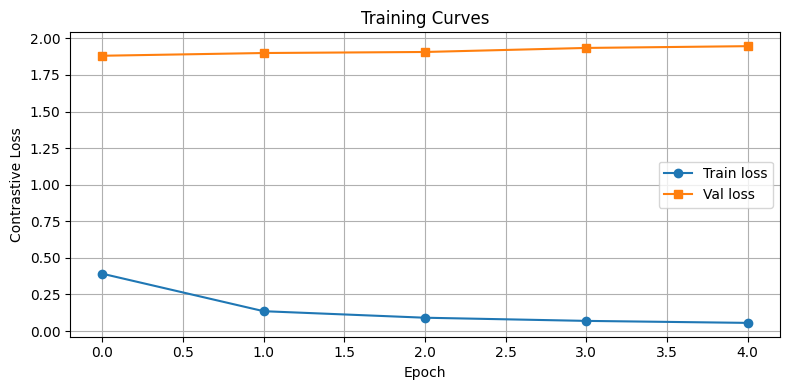

In [20]:
# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss", marker="o")
plt.plot(history["val_loss"],   label="Val loss",   marker="s")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Training Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##Recall@K Evaluation on Validation Set

In [24]:
# Load best checkpoint
ckpt = torch.load(f"{OUTPUT_DIR}/best_clip.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded best checkpoint from epoch {ckpt['epoch']+1}")


@torch.no_grad()
def encode_images(img_ids, image_dir, batch_size=128):
    """Encode a list of image IDs → normalised embeddings."""
    all_embs = []
    for i in tqdm(range(0, len(img_ids), batch_size), desc="Encoding images"):
        chunk = img_ids[i : i + batch_size]
        imgs  = [Image.open(os.path.join(image_dir,
                            id2filename[x])).convert("RGB") for x in chunk]
        inp   = processor(images=imgs, return_tensors="pt",
                          padding=True).to(DEVICE)
        emb   = model.get_image_features(**inp)
        all_embs.append(F.normalize(emb, dim=-1).cpu())
    return torch.cat(all_embs, dim=0)


@torch.no_grad()
def encode_captions(cap_ids, batch_size=256):
    """Encode a list of caption IDs → normalised embeddings."""
    all_embs = []
    for i in tqdm(range(0, len(cap_ids), batch_size), desc="Encoding captions"):
        chunk = cap_ids[i : i + batch_size]

        #Ensure caption is always a string

        caps  = [str(id2caption[x]) for x in chunk]
        inp   = processor(text=caps, return_tensors="pt",
                          padding=True, truncation=True,
                          max_length=MAX_LEN).to(DEVICE)
        emb   = model.get_text_features(**inp)
        all_embs.append(F.normalize(emb, dim=-1).cpu())
    return torch.cat(all_embs, dim=0)


def recall_at_k(sim_matrix, ks=(1, 5, 10)):
    """
    sim_matrix : [N x M] — row i corresponds to query i,
                           correct answer is at column i (diagonal).
    """
    results = {}
    for k in ks:
        top_k   = sim_matrix.topk(k, dim=1).indices
        correct = (torch.arange(len(sim_matrix)).unsqueeze(1) == top_k)
        results[f"R@{k}"] = correct.any(dim=1).float().mean().item() * 100
    return results

Loaded best checkpoint from epoch 1


In [25]:
# Get unique image/caption IDs from val set (preserving order)
val_df_loaded  = pd.read_csv(VAL_CSV)

# Keep only pairs where we have 1 image : 1 representative caption

val_pairs      = val_df_loaded.drop_duplicates("image_id").reset_index(drop=True)
val_img_ids    = val_pairs.image_id.tolist()
val_cap_ids    = val_pairs.caption_id.tolist()

# Encode
val_img_embs = encode_images(val_img_ids,  VAL_IMG_DIR)
val_cap_embs = encode_captions(val_cap_ids)

# Similarity matrix [N x N]
sim = val_img_embs @ val_cap_embs.T

i2t = recall_at_k(sim)
t2i = recall_at_k(sim.T)

print("\n── Image → Text Recall ──")
for k, v in i2t.items(): print(f"  {k}: {v:.2f}%")

print("\n── Text → Image Recall ──")
for k, v in t2i.items(): print(f"  {k}: {v:.2f}%")

rsum = sum(i2t.values()) + sum(t2i.values())
print(f"\n  R-sum (higher = better): {rsum:.2f}")

Encoding images:   0%|          | 0/8 [00:00<?, ?it/s]

Encoding captions:   0%|          | 0/4 [00:00<?, ?it/s]


── Image → Text Recall ──
  R@1: 67.60%
  R@5: 91.40%
  R@10: 94.80%

── Text → Image Recall ──
  R@1: 67.20%
  R@5: 89.70%
  R@10: 94.10%

  R-sum (higher = better): 504.80


##Generate `submission.csv`

In [26]:
# Pre-encode the ENTIRE caption pool and image pool
all_cap_ids = caption_df.caption_id.tolist()
all_img_ids = image_df.image_id.tolist()

print(f"Encoding {len(all_cap_ids):,} captions ...")
cap_pool_embs = encode_captions(all_cap_ids)   # [N_caps, 512]

print(f"Encoding {len(all_img_ids):,} images from image_pool ...")
# Images for the full pool may span train+val+test folders
# Build a path resolver that checks all folders
def resolve_image_path(img_id):
    fname = id2filename[img_id]
    for folder in [TRAIN_IMG_DIR, VAL_IMG_DIR, TEST_IMG_DIR]:
        p = os.path.join(folder, fname)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Image {fname} not found in any folder")

@torch.no_grad()
def encode_images_flexible(img_ids, batch_size=128):
    all_embs = []
    for i in tqdm(range(0, len(img_ids), batch_size), desc="Encoding image pool"):
        chunk = img_ids[i : i + batch_size]
        imgs  = [Image.open(resolve_image_path(x)).convert("RGB") for x in chunk]
        inp   = processor(images=imgs, return_tensors="pt",
                          padding=True).to(DEVICE)
        emb   = model.get_image_features(**inp)
        all_embs.append(F.normalize(emb, dim=-1).cpu())
    return torch.cat(all_embs, dim=0)

img_pool_embs = encode_images_flexible(all_img_ids)   # [N_imgs, 512]
print("Encoding done ✅")

Encoding 50,000 captions ...


Encoding captions:   0%|          | 0/196 [00:00<?, ?it/s]

Encoding 10,000 images from image_pool ...


Encoding image pool:   0%|          | 0/79 [00:00<?, ?it/s]

Encoding done ✅


In [27]:
@torch.no_grad()
def generate_submission(test_df, output_path):
    rows = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df),
                       desc="Generating predictions"):
        qid        = row["id"]
        query_val  = row["query"]
        query_type = row["query_type"]

        if query_type == "image":
            # Encode the test image
            img_path = os.path.join(TEST_IMG_DIR,
                                    id2filename[query_val])
            img = Image.open(img_path).convert("RGB")
            inp = processor(images=img, return_tensors="pt").to(DEVICE)
            q_emb = F.normalize(model.get_image_features(**inp), dim=-1).cpu()

            # Retrieve top-10 captions
            sims    = (q_emb @ cap_pool_embs.T).squeeze(0)
            top10   = sims.topk(10).indices.tolist()
            results = [all_cap_ids[i] for i in top10]

        else:  # query_type == "caption"
            cap = id2caption[query_val]
            inp = processor(text=cap, return_tensors="pt",
                            truncation=True, max_length=MAX_LEN).to(DEVICE)
            q_emb = F.normalize(model.get_text_features(**inp), dim=-1).cpu()

            # Retrieve top-10 images
            sims    = (q_emb @ img_pool_embs.T).squeeze(0)
            top10   = sims.topk(10).indices.tolist()
            results = [all_img_ids[i] for i in top10]

        rows.append({
            "id"  : qid,
            **{f"top{i+1}": results[i] for i in range(10)}
        })

    submission = pd.DataFrame(rows)
    submission.to_csv(output_path, index=False)
    print(f"Saved → {output_path}")
    return submission


sub = generate_submission(test_df, f"{OUTPUT_DIR}/submission.csv")
sub.head()

Generating predictions:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved → /content/outputs/submission.csv


,id,top1,top2,top3,top4,top5,top6,top7,top8,top9,top10
0,1,34143,47109,31151,20680,33604,8775,7398,43215,20569,20567
1,2,49398,44270,44269,49396,42848,49397,39033,44267,40521,26700
2,3,6185,6181,26894,6183,43345,14673,1177,6184,44173,1180
3,4,49081,30967,24763,30985,16625,47987,49085,7058,47553,29950
4,5,25685,10258,30874,30871,10260,48635,42409,35808,30873,10257
